In [6]:
import pandas as pd
from scipy.io import arff
import matplotlib.pyplot as plt
import numpy as np
## Read in data
arff_file_train = arff.loadarff('AbnormalHeartbeat_TRAIN.arff')
df_train = pd.DataFrame(arff_file_train[0])

def plot_heartbeats(start, end, df):
    """
    Plots rows of the original dataframe from start (inclusive) to end (exclusive).
    This plots first 1000 amplitudes of abnormal and normal people separately
    """
    patients = sorted(df['patient_number'].unique())

    for p in patients[start:end]:
        patient_df = df[df['patient_number'] == p]
        patient_df = patient_df[patient_df['att'] < 1000]
        abnormal_df = patient_df[patient_df['target'] == 'Abnormal']
        normal_df = patient_df[patient_df['target'] == 'Normal']
        plt.figure(figsize=(10, 6))
        plt.plot(normal_df['att'], normal_df['amplitude'], label='Normal')
        plt.plot(abnormal_df['att'], abnormal_df['amplitude'], label='Abnormal')
        plt.axhline(y=0, color='gray', alpha = 0.5, linestyle='dashed')
        plt.legend()
        plt.show()

def eda(df):
    df['target'] = df['target'].apply(lambda x: 'Abnormal' if str(x) == "b'Abnormal'" else 'Normal')
    last_row_target = df['target']
    df.drop('target', axis=1, inplace=True)
    df1 = df.stack(future_stack=True).reset_index()
    df1.drop('level_0', axis=1, inplace=True)
    df1['target'] = np.repeat(np.asarray(last_row_target), 18530)
    df1["patient_number"] = df1.index // 18530 + 1
    df1.rename(columns={'level_1': 'att', 0: 'amplitude'}, inplace=True)
    df1['att'] = df1['att'].str.replace('att', '', regex=False).astype(int)
    return df1

# df_train = eda(df_train)
# plot_heartbeats(202, 204, df_train)

## Feature Engineering

### Pre-processing

In [7]:
arff_file_train = arff.loadarff('AbnormalHeartbeat_TRAIN.arff')
arff_file_test = arff.loadarff('AbnormalHeartbeat_TEST.arff')

df_train = pd.DataFrame(arff_file_train[0])
df_test = pd.DataFrame(arff_file_test[0])

df_train['target'] = df_train['target'].apply(lambda x: 'Abnormal' if str(x) == "b'Abnormal'" else 'Normal')
df_train['target'] = df_train['target'].map({'Abnormal': 1, 'Normal': 0})
df_test['target'] = df_test['target'].apply(lambda x: 'Abnormal' if str(x) == "b'Abnormal'" else 'Normal')
df_test['target'] = df_test['target'].map({'Abnormal': 1, 'Normal': 0})
y_train = df_train['target']
y_test = df_test['target']

df_train.drop('target', axis=1, inplace=True)
df_test.drop('target', axis=1, inplace=True)

In [9]:
from scipy.signal import find_peaks
import numpy as np
import pandas as pd

roll_train = df_train.rolling(window=500, axis=1)
range_max_train = roll_train.max().sub(roll_train.min()).max(axis=1)
range_mean_train = roll_train.max().sub(roll_train.min()).mean(axis=1)
std_mean_train = roll_train.std().mean(axis=1)
range_max_train = range_max_train.rename('range_max')
range_mean_train = range_mean_train.rename('range_mean')
std_mean_train = std_mean_train.rename('std_mean')

roll_test = df_test.rolling(window=500, axis=1)
range_max_test = roll_test.max().sub(roll_test.min()).max(axis=1)
range_mean_test = roll_test.max().sub(roll_test.min()).mean(axis=1)
std_mean_test = roll_test.std().mean(axis=1)
range_max_test = range_max_test.rename('range_max')
range_mean_test = range_mean_test.rename('range_mean')
std_mean_test = std_mean_test.rename('std_mean')



# rxtract features
def extract_peak_features(row):
    peaks, props = find_peaks(row, prominence=0.5)

    return pd.Series({
        # we'll return NaNs here and then impute those values later
        'n_peaks': len(peaks),
        'mean_peak_height': row[peaks].mean() if len(peaks) > 0 else np.nan,
        'std_peak_interval': np.std(np.diff(peaks)) if len(peaks) > 1 else np.nan,
        'mean_peak_interval': np.mean(np.diff(peaks)) if len(peaks) > 1 else np.nan,
    })

peak_feats_train = df_train.apply(extract_peak_features, axis=1)
peak_feats_test = df_test.apply(extract_peak_features, axis=1)

# global summary stats
stats_train = pd.DataFrame({
    'mean': df_train.mean(axis=1),
    'std': df_train.std(axis=1),
    'max': df_train.max(axis=1),
    'min': df_train.min(axis=1)
})
stats_test = pd.DataFrame({
    'mean': df_test.mean(axis=1),
    'std': df_test.std(axis=1),
    'max': df_test.max(axis=1),
    'min': df_test.min(axis=1)
})

# This allows us to expand differences. 
# See https://www.sciencedirect.com/topics/engineering/signal-energy#:~:text=Signal%20energy%20is%20defined%20as,on%3A%20Digital%20Signal%20Processing%2C%202017
energy_train = df_train.pow(2).sum(axis=1).rename('energy')
energy_test = df_test.pow(2).sum(axis=1).rename('energy')


X_train = pd.concat([
    range_max_train,
    range_mean_train,
    std_mean_train,
    peak_feats_train,
    stats_train,
    energy_train
], axis=1)
X_test = pd.concat([
    range_max_test,
    range_mean_test,
    std_mean_test,
    peak_feats_test,
    stats_test,
    energy_test
], axis=1)

X_train


,range_max,range_mean,std_mean,n_peaks,mean_peak_height,std_peak_interval,mean_peak_interval,mean,std,max,min,energy
0,0.616577,0.301420,0.050120,2.0,0.284759,0.000000,9977.000000,-0.000044,0.053478,0.291504,-0.325073,52.990642
1,0.227142,0.134099,0.020607,0.0,NaN,NaN,NaN,-0.000026,0.021232,0.139496,-0.109467,8.352996
2,0.514557,0.194842,0.027259,1.0,0.260284,NaN,NaN,-0.000069,0.034246,0.291596,-0.253387,21.730593
3,1.033691,0.513862,0.066154,23.0,0.445164,386.971279,795.045455,-0.000026,0.075535,0.644653,-0.440369,105.717751
4,1.912079,0.799476,0.100792,39.0,0.518660,428.409466,480.473684,-0.000021,0.126612,0.999969,-1.000000,297.029440
...,...,...,...,...,...,...,...,...,...,...,...,...
199,0.404449,0.208737,0.029086,0.0,NaN,NaN,NaN,-0.000015,0.032546,0.205414,-0.242615,19.627304
200,0.467682,0.278383,0.040422,0.0,NaN,NaN,NaN,0.000016,0.043402,0.268433,-0.271423,34.903172
201,0.302978,0.128179,0.020001,0.0,NaN,NaN,NaN,-0.000140,0.022984,0.155762,-0.150848,9.788884
202,1.312469,0.503282,0.063461,24.0,0.442950,597.938604,765.347826,-0.000051,0.079497,0.765869,-0.745911,117.099453


### Model Training & Evaluation

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
import pandas as pd

# Tune Logistic regression

pipe_logreg = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=2000))
])

param_logreg = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l1', 'l2'],
    'logreg__solver': ['liblinear']
}

grid_logreg = GridSearchCV(pipe_logreg, param_logreg, cv=5, scoring='f1')
grid_logreg.fit(X_train, y_train)

best_logreg = grid_logreg.best_estimator_
print("Best Logistic Regression:", grid_logreg.best_params_, grid_logreg.best_score_)


# Tune SVC

pipe_svc = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    ('svc', SVC(probability=True))
])

param_svc = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 0.01, 0.001],
    'svc__kernel': ['rbf', 'poly', 'sigmoid', 'linear']
}

grid_svc = GridSearchCV(pipe_svc, param_svc, cv=5, scoring='f1')
grid_svc.fit(X_train, y_train)

best_svc = grid_svc.best_estimator_
print("Best SVC:", grid_svc.best_params_, grid_svc.best_score_)


# TUne Random Forest

pipe_rf = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('rf', RandomForestClassifier(random_state=42))
])

param_rf = {
    'rf__n_estimators': [100, 300, 500],
    'rf__max_depth': [None, 3, 5, 10],
    'rf__min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(pipe_rf, param_rf, cv=5, scoring='f1')
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print("Best Random Forest:", grid_rf.best_params_, grid_rf.best_score_)

Best Logistic Regression: {'logreg__C': 100, 'logreg__penalty': 'l2', 'logreg__solver': 'liblinear'} 0.8497845944904769
Best SVC: {'svc__C': 100, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'} 0.8561608855750095
Best Random Forest: {'rf__max_depth': None, 'rf__min_samples_split': 5, 'rf__n_estimators': 500} 0.8614451551764984


In [11]:
from sklearn.metrics import accuracy_score, f1_score

y_pred = best_rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.6634146341463415
F1 Score: 0.775244299674267


### flaviagiammarino InceptionTime

#### Preprocessing

In [18]:
# From your ARFF preprocessing, e.g. similar to what you already have
# x_train, y_train, x_test, y_test are pandas objects
df = pd.DataFrame(arff_file_train[0])
df['target'] = df['target'].apply(lambda x: 'Abnormal' if str(x) == "b'Abnormal'" else 'Normal')
df['target'] = df['target'].map({'Abnormal': 1, 'Normal': 0})
x_train = df.drop('target', axis=1)
y_train = df['target']

x_train_full = x_train.to_numpy().astype(np.float32)  # (n_train_patients, 18530)
y_train_full = y_train.to_numpy().astype(np.int64)    # (n_train_patients,)

#### Model Training

In [13]:
!pip install git+https://github.com/flaviagiammarino/inception-time-pytorch

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
  Cloning https://github.com/flaviagiammarino/inception-time-pytorch to /tmp/pip-req-build-em7dgwt1
  Running command git clone --filter=blob:none --quiet https://github.com/flaviagiammarino/inception-time-pytorch /tmp/pip-req-build-em7dgwt1
  Resolved https://github.com/flaviagiammarino/inception-time-pytorch to commit a1285d0c405a16b2cdb60e851904c1810054d15e
ERROR: git+https://github.com/flaviagiammarino/inception-time-pytorch does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


In [25]:
import torch
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

from inception_time_pytorch.modules import InceptionModel


class InceptionTime():
    
    def __init__(self,
                 x,
                 y,
                 filters,
                 depth,
                 models):
        
        '''
        Implementation of InceptionTime model introduced in Ismail Fawaz, H., Lucas, B., Forestier, G., Pelletier,
        C., Schmidt, D.F., Weber, J., Webb, G.I., Idoumghar, L., Muller, P.A. and Petitjean, F., 2020. InceptionTime:
        Finding AlexNet for Time Series Classification. Data Mining and Knowledge Discovery, 34(6), pp.1936-1962.

        Parameters:
        __________________________________
        x: np.array.
            Time series, array with shape (samples, channels, length) where samples is the number of time series,
            channels is the number of dimensions of each time series (1: univariate, >1: multivariate) and length
            is the length of the time series.

        y: np.array.
            Class labels, array with shape (samples,) where samples is the number of time series.

        filters: int.
            The number of filters (or channels) of the convolutional layers of each model.

        depth: int.
            The number of blocks of each model.
        
        models: int.
            The number of models.
        '''
        
        # Check if GPU is available.
        self.device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
        
        # Scale the data.
        self.mu = np.nanmean(x, axis=0, keepdims=True)
        self.sigma = np.nanstd(x, axis=0, keepdims=True)
        x = (x - self.mu) / self.sigma
        
        # Save the data.
        self.x = torch.from_numpy(x).float().to(self.device)
        self.y = torch.from_numpy(y).long().to(self.device)
        
        # Build and save the models.
        self.models = [
            InceptionModel(
                input_size=x.shape[1],
                num_classes=len(np.unique(y)),
                filters=filters,
                depth=depth,
            ).to(self.device) for _ in range(models)
        ]
    
    def fit(self,
            learning_rate,
            batch_size,
            epochs,
            verbose=True):
        
        '''
        Train the models.

        Parameters:
        __________________________________
        learning_rate: float.
            Learning rate.

        batch_size: int.
            Batch size.

        epochs: int.
            Number of epochs.

        verbose: bool.
            True if the training history should be printed in the console, False otherwise.
        '''
        
        # Generate the training dataset.
        dataset = torch.utils.data.DataLoader(
            dataset=torch.utils.data.TensorDataset(self.x, self.y),
            batch_size=batch_size,
            shuffle=True
        )
        
        for m in range(len(self.models)):
            
            # Define the optimizer.
            optimizer = torch.optim.Adam(self.models[m].parameters(), lr=learning_rate)
            
            # Define the loss function.
            loss_fn = torch.nn.CrossEntropyLoss()
            
            # Train the model.
            print(f'Training model {m + 1} on {self.device}.')
            self.models[m].train(True)
            for epoch in range(epochs):
                for features, target in dataset:
                    optimizer.zero_grad()
                    output = self.models[m](features.to(self.device))
                    loss = loss_fn(output, target.to(self.device))
                    loss.backward()
                    optimizer.step()
                    accuracy = (torch.argmax(torch.nn.functional.softmax(output, dim=-1), dim=-1) == target).float().sum() / target.shape[0]
                if verbose:
                    print('epoch: {}, loss: {:,.6f}, accuracy: {:.6f}'.format(1 + epoch, loss, accuracy))
            self.models[m].train(False)
            print('-----------------------------------------')
    
    def predict(self, x):
        
        '''
        Predict the class labels.

        Parameters:
        __________________________________
        x: np.array.
            Time series, array with shape (samples, channels, length) where samples is the number of time series,
            channels is the number of dimensions of each time series (1: univariate, >1: multivariate) and length
            is the length of the time series.

        Returns:
        __________________________________
        y: np.array.
            Predicted labels, array with shape (samples,) where samples is the number of time series.
        '''

        # Scale the data.
        x = torch.from_numpy((x - self.mu) / self.sigma).float().to(self.device)
        
        # Get the predicted probabilities.
        with torch.no_grad():
            p = torch.concat([torch.nn.functional.softmax(model(x), dim=-1).unsqueeze(-1) for model in self.models], dim=-1).mean(-1)
        
        # Get the predicted labels.
        y = p.argmax(-1).detach().cpu().numpy().flatten()

        return y

ModuleNotFoundError: No module named 'torch'

In [24]:
from inception_time_pytorch.model import InceptionTime
import torch

model = InceptionTime(
    # I tried a rolling window approach here but couldn't seem to figure it out
    x=x_train_win,
    y=y_train_win,
    filters=32,
    depth=6,
    models=1,
)

# model.fit(
#     learning_rate=0.001,
#     batch_size=64,
#     epochs=10,
#     verbose=True,
# )



ModuleNotFoundError: No module named 'inception_time_pytorch'

## Code we might not wanna throw

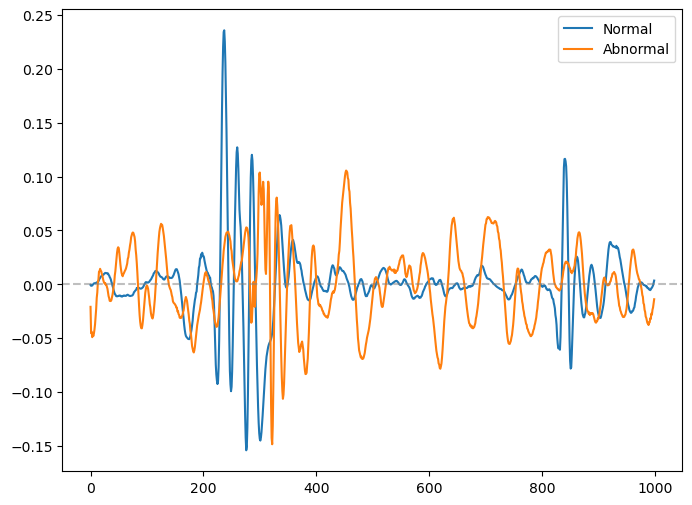

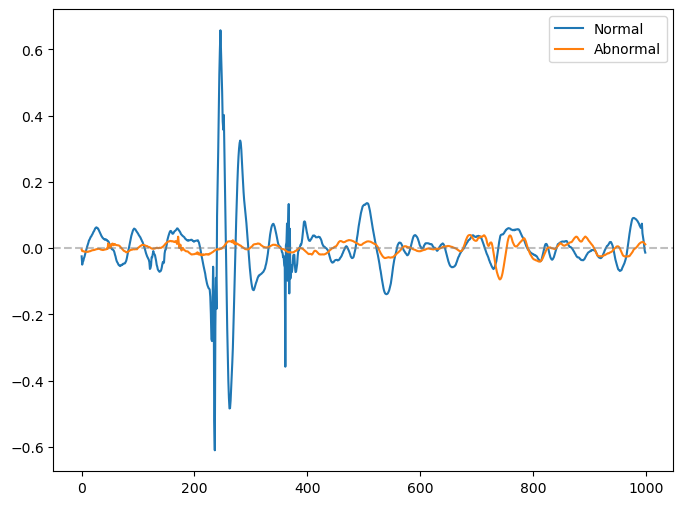

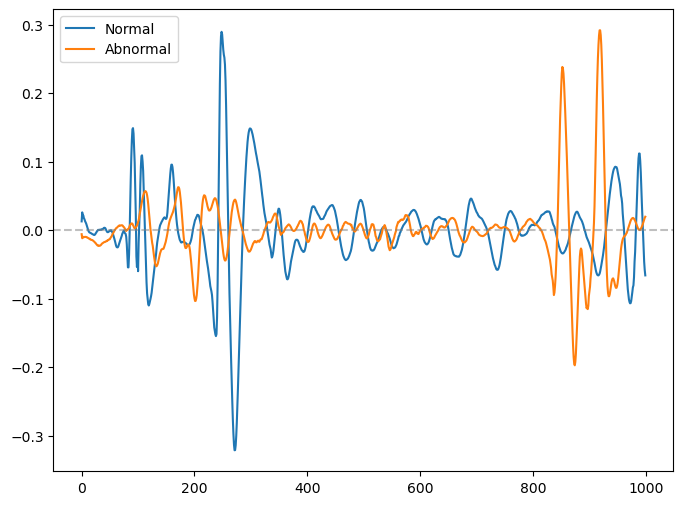

In [16]:
# NOTE: Keeping this here in case we want to look at it again. This plots the first 1000 timestamps 
# of amplitudes of first 3 normal and abnormal patients
arff_file = arff.loadarff('AbnormalHeartbeat_TRAIN.arff')
df = pd.DataFrame(arff_file[0])
df['target'] = df['target'].apply(lambda x: 'Abnormal' if str(x) == "b'Abnormal'" else 'Normal')
abnormal = df.loc[df['target'] == 'Abnormal']
normal = df.loc[df['target'] == 'Normal']
for i in range(3):
    ab_x_first = abnormal.select_dtypes(include=['number']).T.iloc[:,i]
    n_x_first = normal.select_dtypes(include=['number']).T.iloc[:,i]
    plt.figure(figsize=(8,6))
    plt.plot(range(len(n_x_first))[0:1000], n_x_first[0:1000], label = 'Normal')
    plt.plot(range(len(ab_x_first))[0:1000], ab_x_first[0:1000], label = 'Abnormal')
    plt.axhline(y=0, color='gray', alpha = 0.5, linestyle='dashed')
    plt.legend()
    plt.show()

In [38]:
# train imbalance #remove hashtags if we use inception time
#cb_train = df_train.value_counts('target')/len(df_train)
#cb_train

In [19]:
# load train set
arff_file = arff.loadarff('AbnormalHeartbeat_TRAIN.arff')
test = pd.DataFrame(arff_file[0])
test['target'] = test['target'].apply(lambda x: 'Abnormal' if str(x) == "b'Abnormal'" else 'Normal')

# test class imbalance
cb_test = test.value_counts('target')/len(df)
cb_test

target
Abnormal    0.730392
Normal      0.269608
Name: count, dtype: float64

In [39]:
# overall class imbalance
#(cb_train + cb_test)/2 (i dont have the (cb_test, so change if we end up using inception time)

In [36]:
from scipy.signal import find_peaks, welch
import numpy as np
import pandas as pd

#IMPROVED Peak Detection
def extract_peak_features_v2(row):
    # CHANGED Lowered prominence from 0.5 to catch smaller peaks. feel free to change again
    peaks, props = find_peaks(row, prominence=0.01, distance=50)
    
    n_peaks = len(peaks)
    
    if n_peaks > 0:
        mean_height = row[peaks].mean()
        mean_int = np.mean(np.diff(peaks)) if n_peaks > 1 else 0
        std_int = np.std(np.diff(peaks)) if n_peaks > 1 else 0
    else:
        mean_height = 0
        mean_int = 0
        std_int = 0

    return pd.Series({
        'n_peaks': n_peaks,
        'mean_peak_height': mean_height,
        'mean_peak_interval': mean_int, # HRV proxy
        'std_peak_interval': std_int    # Irregularity proxy
    })

#NEW: Frequency Domain Features (FFT/PSD)
def extract_freq_features(row):
    freqs, psd = welch(row, nperseg=1024)
    
 
    total_power = np.sum(psd)
    max_power = np.max(psd)
    mean_power = np.mean(psd)
    
    
    psd_norm = psd / total_power
    spectral_entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-10))

    return pd.Series({
        'total_power': total_power,
        'max_power': max_power,
        'spectral_entropy': spectral_entropy
    })

print("Extracting improved features...")

peak_train = df_train.apply(extract_peak_features_v2, axis=1)
peak_test = df_test.apply(extract_peak_features_v2, axis=1)


freq_train = df_train.apply(extract_freq_features, axis=1)
freq_test = df_test.apply(extract_freq_features, axis=1)

X_train_v2 = pd.concat([range_max_train, range_mean_train, std_mean_train, peak_train, freq_train, energy_train], axis=1)
X_test_v2 = pd.concat([range_max_test, range_mean_test, std_mean_test, peak_test, freq_test, energy_test], axis=1)

print("New Feature Set Ready: X_train_v2")

Extracting improved features...
New Feature Set Ready: X_train_v2


In [37]:
# Updated Random Forest with class_weight
pipe_rf_v2 = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    # Added class_weight='balanced' to handle the 73/27 split
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

param_rf = {
    'rf__n_estimators': [100, 300],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(pipe_rf_v2, param_rf, cv=5, scoring='f1')
grid_rf.fit(X_train_v2, y_train)

pipe_rf_v2
print("New Score:", grid_rf.best_score_)

New Score: 0.8574883713628673
